In [32]:
import keras
import numpy as np
from keras.datasets import mnist

In [33]:
(x_tr, y_tr), (x_te, y_te) = mnist.load_data()

In [34]:
x_tr.shape, x_te.shape, y_tr.shape, y_te.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [35]:
import matplotlib.pyplot as plt
%matplotlib inline

label: 5


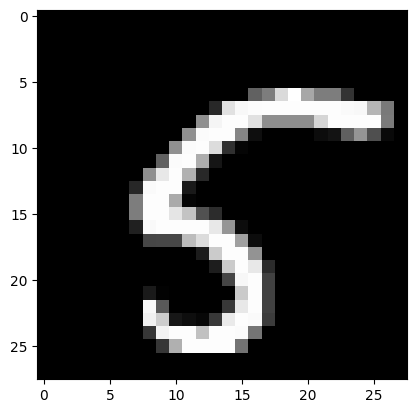

In [36]:
data_index = np.random.randint(60000)
print(f"label: {y_tr[data_index]}")
plt.imshow(x_tr[data_index], cmap='gray')
plt.show()

In [37]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Convolution2D, MaxPooling2D, Flatten

In [38]:
MNIST_NN = Sequential()
MNIST_NN.add(Convolution2D(10, (5, 5), input_shape=(28, 28, 1)))
MNIST_NN.add(MaxPooling2D(pool_size=(2, 2)))
MNIST_NN.add(Convolution2D(10, (5, 5), padding='same'))
MNIST_NN.add(MaxPooling2D(pool_size=(2, 2)))
MNIST_NN.add(Convolution2D(10, (5, 5), padding='same'))
MNIST_NN.add(MaxPooling2D(pool_size=(2, 2)))
MNIST_NN.add(Flatten())
MNIST_NN.add(Dense(10, activation='softmax'))
             

c:\Users\tommagom\Documents\personaldata\mytools\learning-note\ml\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
from tensorflow.keras.utils import to_categorical

X_tr = x_tr.reshape(60000, 28, 28, 1).astype('float32') / 255
X_te = x_te.reshape(10000, 28, 28, 1).astype('float32') / 255
Y_tr = to_categorical(y_tr, 10)
Y_te = to_categorical(y_te, 10)

X_tr.shape, X_te.shape, Y_tr.shape, Y_te.shape


((60000, 28, 28, 1), (10000, 28, 28, 1), (60000, 10), (10000, 10))

In [40]:
MNIST_NN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [41]:
from keras.callbacks import EarlyStopping
MNIST_NN.fit(X_tr, Y_tr, epochs=1, batch_size=128, validation_data=(X_te, Y_te), callbacks=[EarlyStopping(patience=3)])

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8730 - loss: 0.4183 - val_accuracy: 0.9555 - val_loss: 0.1437


In [43]:
MNIST_NN.save('MNIST_NN.h5')

In [44]:
from keras.models import load_model
Loaded_NN = load_model('MNIST_NN.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
予言= 0


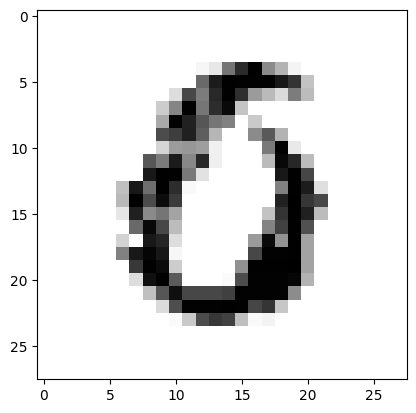

In [45]:
data_index = np.random.randint(10000)
predicted = Loaded_NN.predict(x_te[data_index].reshape(1, 28, 28, 1).astype('float32') / 255)
print('予言=', np.argmax(predicted))
plt.imshow(x_te[data_index], cmap=plt.cm.gray_r)
plt.show()

In [46]:
MNIST_NN_99 = load_model('MNIST_NN_99.h5')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'MNIST_NN_99.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)